the Sample Rate is :  44100
The number of samples is  549888
Duration of audio:  12.469115646258503


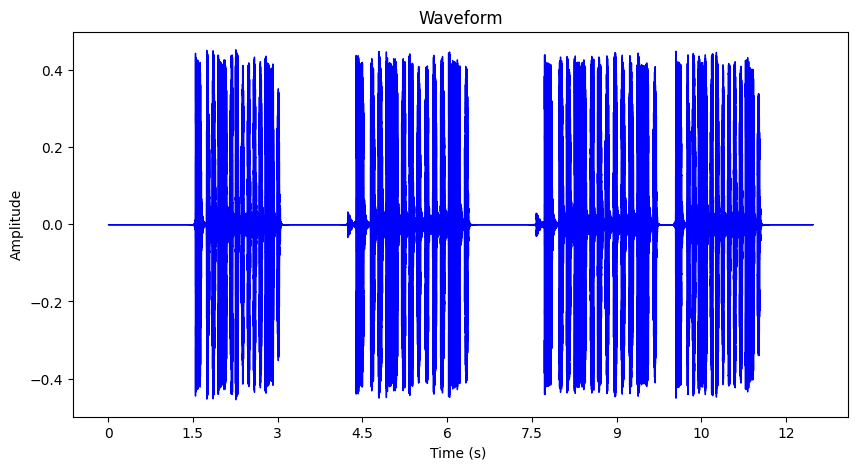

In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np


# audio_waveform is a list of amplitudes of samples mades.
# if sample rate is x, each second of audio is split into x discrete samples.
# upload the file and name it 'song.mp3'
audio_waveform, sample_rate = librosa.load("song.mp3", sr= None, mono= True)
print("the Sample Rate is : ", sample_rate)
duration = len(audio_waveform) / sample_rate
print("The number of samples is ", len(audio_waveform))
print("Duration of audio: ", duration)

#lets visualize the audio waveform
plt.figure(figsize=(10,5))
librosa.display.waveshow(audio_waveform, sr = sample_rate, color = "blue")
plt.title("Waveform")
plt.xlabel("Time (s) ")
plt.ylabel("Amplitude")
plt.show()


In [2]:
# Use STFT(Short time Fourier Transform) to get a timeline of which frequencies are active at each given moment
#honestly there some every amazing math behind the fourier transform .the concept is very interesting.
stft = librosa.stft(audio_waveform)  #stft is a complex valued matrix
print("STFT:")
print(stft.ndim)
print(stft.shape)
print(stft[:5,:5], end="\n\n")
print(np.abs(stft))
## so i did more research and found that its easier to use pYIN algo for the project.
# So there are multiple frequencies playing together at every moment, we can use stft to visualize that.

STFT:
2
(1025, 1075)
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/tmp/ipykernel_6263/3261753669.py:3: UserWarning: With fmin=32.703, sr=44100 and frame_length=2048, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=43.066 or frame_length=2699.
  f0 , voiced_flag , voiced_prob = librosa.pyin(audio_waveform , sr = sample_rate, fmin =librosa.note_to_hz("C1") , fmax = librosa.note_to_hz("C6"),hop_length=512 )


[nan nan nan ... nan nan nan]
1075
[0. 0. 0. ... 0. 0. 0.]


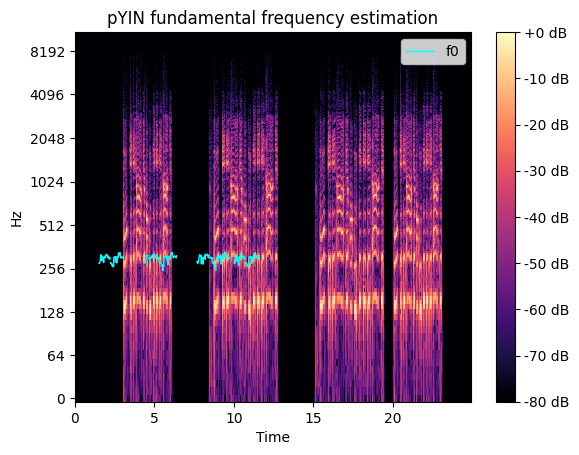

In [3]:
# So basically , i want to play a melody using a passive buzzer so i can only play a single frequency at a time, so i'm gonna use
#pYIN algo to extract the fundamental frequency , YIN is used in pitch detection.
f0 , voiced_flag , voiced_prob = librosa.pyin(audio_waveform , sr = sample_rate, fmin =librosa.note_to_hz("C1") , fmax = librosa.note_to_hz("C6"),hop_length=512 )
#f0 gives the time series of fundamental frequencies , voiced_flag : a boolean list indicating if frame is voiced or not
# voiced_prob: time series of probs that a freq is voiced .

# the frequencies will be mapped ranging from note C1~30 hz to not C6 ~1046 hz.
# as this range is easily distinguished by humans and the buzzer can play a max of 2k hz.
# honestly ig like 1.5k+ it just seems the same.

# lets plot a spectogram of the audio, its unneccesary but looks cool and helps to visualize our aim.
# we will also check out the fundamental frequency


times = librosa.times_like(f0, sr=sample_rate)

spectogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
fig , ax = plt.subplots()
image = librosa.display.specshow(spectogram, x_axis="time", y_axis="log",  ax=ax)
fig.colorbar(image, ax = ax, format="%+2.f dB")
ax.set(title= "pYIN fundamental frequency estimation")
ax.plot(times, f0, label='f0', color='cyan', linewidth=1)
ax.legend(loc='upper right')

print(f0)
print(len(f0))
frequencies = np.nan_to_num(f0)  # if no audio is played, its assigned as NaN.
print(frequencies)

# isnt that a cool graph

In [11]:
# you can just copy frequencies and feed them to the buzzer , but the arduino has limited memory
# so instead of the frequencies being float i'll convert them to int. the arduino will just do this for you before feeding
# the value to buzzer but, i'm doing this to conserve memory.
fint= []
for i, f in enumerate(frequencies):
  fint.append(int(f))
#remove the ending 0s
i = len(fint) -1
while fint[i] == 0:
  fint.pop()
  i-=1

#remove starting 0s
i = 0
while fint[i] == 0 :
  i+=1
fint = fint[i:]



# you can get the frequencies from here.
print(*fint, sep=",")

278,278,278,278,280,283,288,297,304,309,312,320,318,312,311,311,312,290,304,300,300,300,300,302,302,282,307,305,305,307,307,309,312,305,0,0,318,318,318,318,320,322,322,320,314,307,305,305,305,309,312,0,0,300,305,307,307,307,307,304,298,0,282,278,278,278,278,280,277,277,270,270,267,269,267,267,270,263,273,267,305,305,307,309,309,309,309,0,285,305,307,309,309,309,309,307,280,290,304,305,305,307,307,309,307,327,0,0,0,318,320,325,327,331,331,327,320,309,305,304,304,307,0,0,0,304,305,307,307,309,309,307,307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,282,282,282,280,280,280,282,286,293,300,307,311,314,318,318,318,312,311,312,312,314,316,0,302,304,302,302,302,300,302,304,277,0,304,307,305,305,305,305,307,311,312,314,304,307,0,320,318,318,318,318,318,320,320,322,322,322,318,312,307,304,304,307,309,312,316,0,0,0,0,30

In [12]:
#frame duration = hop_length / sample_rate
t = int((512 / sample_rate) * 1000)
print(t)
# get the frame duration of each freq from here.


11


In [57]:
# So the project is basically over here. but a certain ass LLM had an idea to improve my program which didnt do shit.
# if you do go throught the rest of the project , the resulting audio is just a background hiss
# you can go through the rest but the arduino code works with the project till here .



# So one suggestion to improve the quality is mapping every freq to a Note that is know to us.
# gotta use hz_to_note
# one huge error i got was this: internally, formula is m = log ( f ) smthg, so if frequency is 0, m = - infinity
fres = []
for f in fint:
  if f !=0:
    fres.append(int(librosa.note_to_hz(librosa.hz_to_note(f))))
  if f == 0:
    fres.append(0)
print(*fres, sep=",")
#print(len(fres))



#for repeated freq, instead of turning of and on again and again, add the durations of each similar simultaneous freq.
final_freq =[]
final_duration = []

i=0
while(i < len(fres)):
  j = i +1
  while j < len(fres) -1 and fres[i] == fres[j]:
    dur[i] += dur[j]
    j+=1
  final_freq.append(fres[i])
  final_duration.append(dur[i])
  i = j

#print(*final_freq, sep=",")

#print(*final_duration)


0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,277,277,277,277,277,277,293,293,311,311,311,311,311,311,311,311,311,293,311,293,293,293,293,293,293,277,311,311,311,311,311,311,311,311,0,0,311,311,311,311,311,329,329,311,311,311,311,311,311,311,311,0,0,293,311,311,311,311,311,311,293,0,277,277,277,277,277,277,277,277,277,277,261,261,261,261,277,261,277,261,311,311,311,311,311,311,311,0,277,311,311,311,311,311,311,311,277,293,311,311,311,311,311,311,311,329,0,0,0,311,311,329,329,329,329,329,311,311,311,311,311,311,0,0,0,311,311,311,311,311,311,311,311,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,277,27